<a href="https://colab.research.google.com/github/GarzonDiegoINL/Characterization/blob/main/GDOES_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GDOES Depth Profile Analysis

Processes **Glow Discharge Optical Emission Spectroscopy (GDOES)** depth profile files to visualize elemental concentration profiles and estimate layer thicknesses.

GDOES sputters through a thin-film stack and measures elemental concentration as a function of depth, making it ideal for characterizing multilayer structures (e.g., ZnO / CdS / CIGS / Mo / Glass).

**Layer thickness** is estimated from the **Full Width at Half Maximum (FWHM)** of each element's depth profile — the depth range over which the signal exceeds 50% of its peak value.

| Input | Output |
|---|---|
| `.txt` depth profile files (tab-separated, two header lines), one per sample | `{filename}_depth_profile.png` — depth profile plot |
| | `{filename}_fwhm_results.xlsx` — FWHM thickness table |

**Instructions:** Place all `.txt` files in the working directory and run all cells in order.

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Elements with a peak below this threshold (mol%) are skipped in FWHM analysis
MIN_MAX_THRESHOLD = 1.0

COLORS = [
    "black", "red", "blue", "magenta", "green",
    "navy", "purple", "deeppink", "darkred", "olive", "cornflowerblue",
    "orange", "gold", "teal", "cyan", "lime",
    "indigo", "salmon", "turquoise", "brown"
]

# Substrings identifying derived ratio columns — FWHM thickness is not computed
# for these because their values are masked to the host-element layer and do not
# represent a distinct physical layer.
RATIO_SUBSTRINGS = ['GGI', 'CGI', 'Se/Sb']

## FWHM Crossing Detection

Finds the two depth positions where a signal crosses its half-maximum value using linear interpolation between adjacent data points. If only one crossing is found (e.g., the signal reaches the edge of the scan), the boundary of the measured range is used as the second boundary. Returns `None` if the signal peak is below `MIN_MAX_THRESHOLD`.

In [ ]:
def find_half_max_crossings(x, y, depth_unit):
    """
    Find the two x-positions where y crosses half-max,
    using linear interpolation for precision.
    Returns None if the signal peak is below MIN_MAX_THRESHOLD.
    """
    y_max = np.nanmax(y)
    half_max = y_max / 2.0

    if y_max < MIN_MAX_THRESHOLD or not np.isfinite(y_max):
        return None

    shifted = y - half_max

    crossings_x = []
    crossings_y = []
    for i in range(len(shifted) - 1):
        s0, s1 = shifted[i], shifted[i + 1]
        if np.isnan(s0) or np.isnan(s1):
            continue
        if s0 * s1 < 0:
            dx = x[i + 1] - x[i]
            if dx == 0:
                continue
            frac = -s0 / (s1 - s0)
            x_cross = x[i] + dx * frac
            y_cross = y[i] + (y[i + 1] - y[i]) * frac
            crossings_x.append(x_cross)
            crossings_y.append(y_cross)

    if len(crossings_x) == 0:
        return None

    if len(crossings_x) == 1:
        xc, yc = crossings_x[0], crossings_y[0]
        peak_idx = np.nanargmax(y)
        if xc < x[peak_idx]:
            x1, y1 = xc, yc
            x2, y2 = x[-1], y[-1]
        else:
            x1, y1 = x[0], y[0]
            x2, y2 = xc, yc
    else:
        x1, x2 = crossings_x[0], crossings_x[-1]
        y1, y2 = crossings_y[0], crossings_y[-1]

    return {
        "Max": round(y_max, 4),
        "50%": round(half_max, 4),
        "y1": round(y1, 4),
        "y2": round(y2, 4),
        "X1": round(x1, 4),
        "X2": round(x2, 4),
        f"thickness [{depth_unit}]": round(abs(x2 - x1), 4),
    }

## File Processing

Loads a GDOES `.txt` file, masks derived ratio columns (GGI, CGI, Se/Sb) to their relevant host-element layer, plots the full depth profile, computes FWHM for all element columns, and exports the results.

**Derived ratio masking:**
- **GGI** (Ga/(Ga+In)): masked where Ga < 50% of its peak — only meaningful within the CIGS absorber layer
- **CGI** (Cu/(Ga+In)): masked where Cu < 50% of its peak — same rationale
- **Se/Sb**: masked where Sb < 50% of its peak — only meaningful within the Sb₂Se₃ layer

In [ ]:
def process_file(filepath):
    basename = os.path.splitext(os.path.basename(filepath))[0]
    print(f"\n{'='*70}")
    print(f"  Processing: {filepath}")
    print(f"{'='*70}")

    # ── Load data ─────────────────────────────────────────────────────────
    with open(filepath) as f:
        _meta = f.readline()
        header_line = f.readline()

    col_names = [c.strip() for c in header_line.strip().split("\t")]

    raw = pd.read_csv(
        filepath, sep="\t", skiprows=2, header=None,
        na_values=["-nan(ind)", "nan", "NaN", "-nan"],
    )
    raw = raw.dropna(axis=1, how="all")
    raw.columns = col_names[: raw.shape[1]]

    depth_col = col_names[0]
    element_cols = list(raw.columns[1:])

    # Extract depth unit from column name (e.g. "Depth [$\mu$m]" → "$\mu$m")
    depth_unit = r"$\mu$m"
    if "[" in depth_col and "]" in depth_col:
        depth_unit = depth_col.split("[")[1].split("]")[0].strip()

    depth = pd.to_numeric(raw[depth_col], errors="coerce").values
    elements = {
        col: pd.to_numeric(raw[col], errors="coerce").fillna(0).values
        for col in element_cols
    }

    sort_idx = np.argsort(depth)
    depth = depth[sort_idx]

    # Pre-locate host columns for ratio masking (None if not present in this file)
    ga_col = next((x for x in element_cols if 'Ga' in x and 'GGI' not in x and 'CGI' not in x), None)
    cu_col = next((x for x in element_cols if 'Cu' in x and 'CGI' not in x), None)
    sb_col = next((x for x in element_cols if 'Sb' in x and 'Se/Sb' not in x), None)

    for col in element_cols:
        elements[col] = elements[col][sort_idx]

        # Mask GGI values outside the CIGSe layer (requires Ga column)
        if 'GGI' in col:
            if ga_col is not None:
                elements[col][elements[ga_col] < elements[ga_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'GGI' column found but no Ga column — skipping mask for {col}")

        # Mask CGI values outside the CIGSe layer (requires Cu column)
        if 'CGI' in col:
            if cu_col is not None:
                elements[col][elements[cu_col] < elements[cu_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'CGI' column found but no Cu column — skipping mask for {col}")

        # Mask Se/Sb values outside the Sb2Se3 layer (requires Sb column)
        if 'Se/Sb' in col:
            if sb_col is not None:
                elements[col][elements[sb_col] < elements[sb_col].max() / 2] = np.nan
            else:
                print(f"  Warning: 'Se/Sb' column found but no Sb column — skipping mask for {col}")

    print(f"Loaded {len(depth)} points, {len(element_cols)} columns.")
    print(f"Depth range: {depth.min():.4f} – {depth.max():.4f} {depth_unit}")
    print(f"Columns: {', '.join(element_cols)}")

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, col in enumerate(element_cols):
        ax.plot(depth, elements[col], label=col,
                color=COLORS[i % len(COLORS)], linewidth=1.3)

    ax.set_xlabel(depth_col)
    ax.set_ylabel("Mol Conc. [%]")
    ax.set_title(basename)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9, frameon=True)
    ax.set_xlim(depth.min() - 0.05, depth.max() + 0.05)
    ax.set_ylim(-2, 105)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    png_file = f"{basename}_depth_profile.png"
    plt.savefig(png_file, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved as {png_file}")

    # ── FWHM calculation ──────────────────────────────────────────────────
    results = {}

    for col in element_cols:
        if not any(r in col for r in RATIO_SUBSTRINGS):
            res = find_half_max_crossings(depth, elements[col], depth_unit)
            if res is not None:
                results[col] = res
            else:
                ymax = np.nanmax(elements[col])
                results[col] = {
                    "Max": round(ymax, 4) if np.isfinite(ymax) else ymax,
                    "50%": round(ymax / 2, 4) if np.isfinite(ymax) else ymax,
                    "y1": None, "y2": None,
                    "X1": None, "X2": None,
                    f"thickness [{depth_unit}]": None,
                }

    df_results = pd.DataFrame(results).T
    df_results.index.name = "Element"

    print(f"\n{df_results.to_string()}\n")

    xlsx_file = f"{basename}_fwhm_results.xlsx"
    df_results.to_excel(xlsx_file)
    print(f"Table saved as {xlsx_file}")

## Run Analysis

Finds all `.txt` files in the working directory and processes them sequentially. Each file produces a depth profile plot and an FWHM results table.

Found 3 .txt file(s): ['260306_Sb2Se3_inl_oxidize.txt', '260309_Sb2Se2_inl_1.txt', '260317_Sb2Se3_INL_2(all).txt']

  Processing: 260306_Sb2Se3_inl_oxidize.txt
Loaded 1694 points, 12 columns.
Depth range: 0.0006 – 1.2770 μm
Columns: C 166, Se 196, Sb 207, Mo 386, Na 589, Zn 330, Al 396, Si 288, Cd 228, S 181, O 777, *Se/Sb!


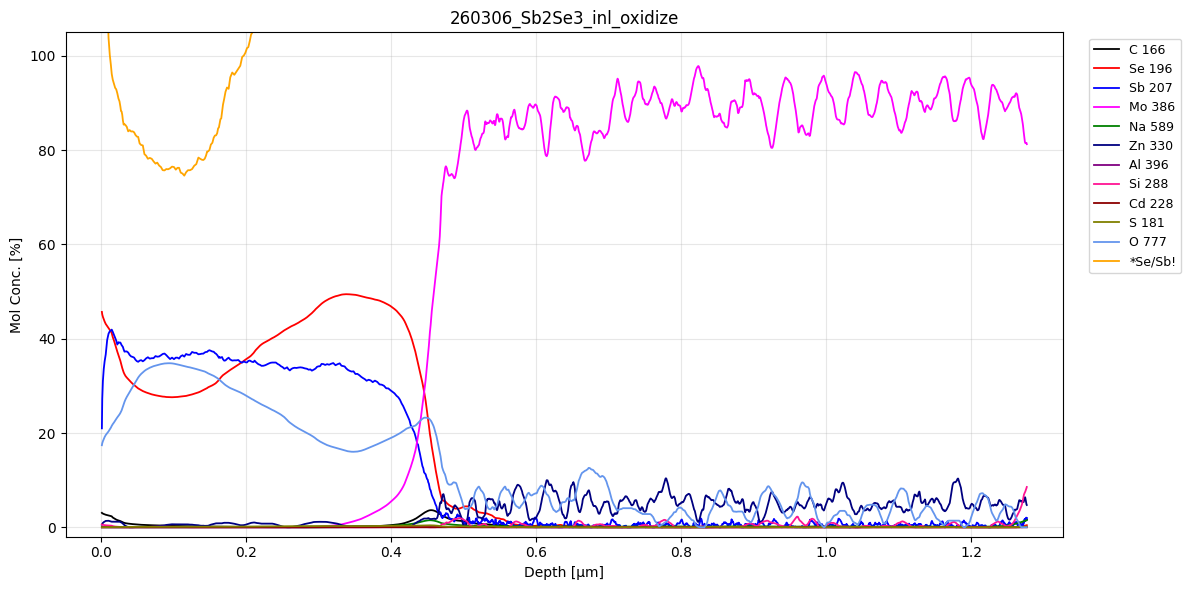

Plot saved as 260306_Sb2Se3_inl_oxidize_depth_profile.png

             Max      50%       y1       y2      X1      X2  thickness [μm]
Element                                                                    
C 166     3.6360   1.8180   1.8180   1.8180  0.0183  0.4796          0.4613
Se 196   49.4500  24.7250  45.6900  24.7250  0.0006  0.4493          0.4487
Sb 207   41.9400  20.9700  20.9900  20.9700  0.0006  0.4291          0.4285
Mo 386   97.8500  48.9250  48.9250  81.2800  0.4580  1.2770          0.8190
Na 589    1.4990   0.7495   0.7495   0.7495  0.4293  1.2614          0.8321
Zn 330   10.4000   5.2000   5.2000   5.2000  0.4675  1.2762          0.8087
Al 396    0.0954   0.0477      NaN      NaN     NaN     NaN             NaN
Si 288    8.5530   4.2765   4.2765   8.5530  1.2691  1.2770          0.0079
Cd 228    0.0826   0.0413      NaN      NaN     NaN     NaN             NaN
S 181     0.4190   0.2095      NaN      NaN     NaN     NaN             NaN
O 777    34.8000  17.4000  17

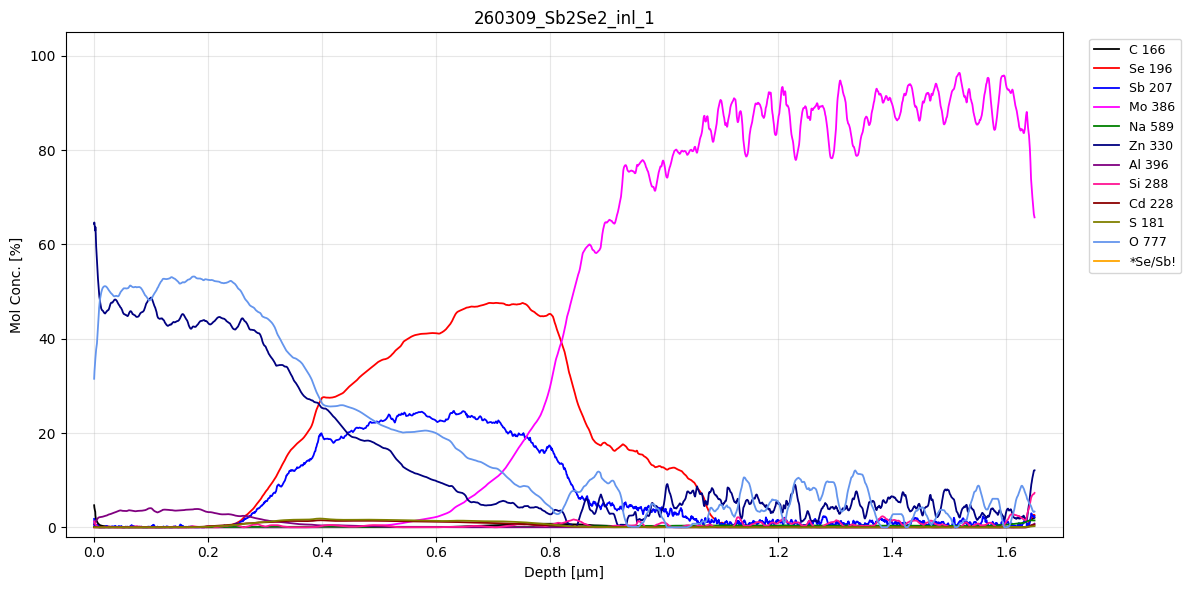

Plot saved as 260309_Sb2Se2_inl_1_depth_profile.png

            Max      50%       y1       y2      X1      X2  thickness [μm]
Element                                                                   
C 166     4.674   2.3370   4.6740   2.3370  0.0001  0.0024          0.0023
Se 196   47.610  23.8050  23.8050  23.8050  0.3873  0.8568          0.4695
Sb 207   24.690  12.3450  12.3450  12.3450  0.3543  0.8261          0.4718
Mo 386   96.400  48.2000  48.2000  65.7500  0.8376  1.6497          0.8121
Na 589    1.475   0.7375   0.7375   1.4550  1.6149  1.6497          0.0348
Zn 330   64.670  32.3350  64.3900  32.3350  0.0001  0.3457          0.3456
Al 396    4.062   2.0310   2.0310   2.0310  0.0075  0.2805          0.2730
Si 288    7.289   3.6445   3.6445   7.2890  1.6389  1.6497          0.0108
Cd 228    1.491   0.7455   0.7455   0.7455  0.2594  0.7378          0.4784
S 181     1.854   0.9270   0.9270   0.9270  0.2828  0.7666          0.4838
O 777    53.220  26.6100  31.5100  26.6100  0.0

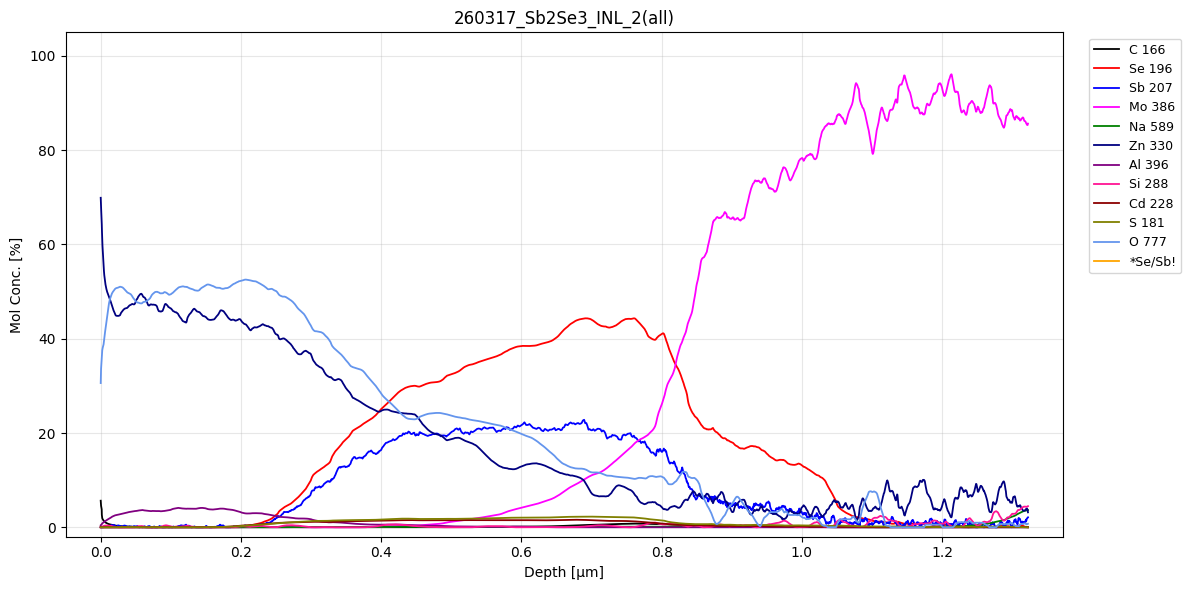

Plot saved as 260317_Sb2Se3_INL_2(all)_depth_profile.png

            Max     50%      y1      y2      X1      X2  thickness [μm]
Element                                                                
C 166     5.640   2.820   5.640   2.820  0.0000  0.0016          0.0016
Se 196   44.330  22.165  22.165  22.165  0.3768  0.8546          0.4777
Sb 207   22.810  11.405  11.405  11.405  0.3354  0.8317          0.4963
Mo 386   96.090  48.045  48.045  85.640  0.8461  1.3224          0.4763
Na 589    3.652   1.826   1.826   3.652  1.2924  1.3224          0.0300
Zn 330   69.900  34.950  69.900  34.950  0.0000  0.3053          0.3053
Al 396    4.124   2.062   2.062   2.062  0.0145  0.2692          0.2547
Si 288    4.482   2.241   2.241   2.241  1.1096  1.2960          0.1864
Cd 228    1.602   0.801   0.801   0.801  0.2445  0.8011          0.5566
S 181     2.262   1.131   1.131   1.131  0.2809  0.8106          0.5297
O 777    52.550  26.275  30.600  26.275  0.0000  0.4139          0.4139

Table

In [ ]:
txt_files = sorted([f for f in glob.glob("*.txt")
                    if not f.endswith("_fwhm_results.txt")])
if not txt_files:
    print("No .txt files found in the current directory.")
else:
    print(f"Found {len(txt_files)} .txt file(s): {txt_files}")
    for f in txt_files:
        process_file(f)
    print(f"\n{'='*70}")
    print("All done!")
    print(f"{'='*70}")

## Interactive Depth Profile

Single Plotly figure with a dropdown to switch between files.  
Each file has two entries in the dropdown: one showing element lines only, and one with **FWHM boundary** dashed lines overlaid.  
Click element names in the legend to hide/show individual lines.

In [ ]:
import plotly.graph_objects as go

In [ ]:
def plot_interactive_gdoes(txt_files):
    """
    Interactive Plotly depth-profile viewer.

    Dropdown (2 entries per file):
      - "<basename>"         → element concentration lines only
      - "<basename> + FWHM"  → concentration lines + dashed FWHM boundary lines

    Legend click: hide / show individual elements.
    Hover: depth + mol% + element name.
    """

    # ── 1. Load & process all files ───────────────────────────────────────
    all_data = {}  # basename → dict

    for filepath in txt_files:
        basename = os.path.splitext(os.path.basename(filepath))[0]

        with open(filepath) as f:
            f.readline()                        # metadata line
            header_line = f.readline()

        col_names = [c.strip() for c in header_line.strip().split("\t")]

        raw = pd.read_csv(
            filepath, sep="\t", skiprows=2, header=None,
            na_values=["-nan(ind)", "nan", "NaN", "-nan"],
        )
        raw = raw.dropna(axis=1, how="all")
        raw.columns = col_names[: raw.shape[1]]

        depth_col   = col_names[0]
        element_cols = list(raw.columns[1:])

        depth_unit = r"µm"
        if "[" in depth_col and "]" in depth_col:
            depth_unit = depth_col.split("[")[1].split("]")[0].strip()
            # strip LaTeX markup for display
            depth_unit = depth_unit.replace(r"$\mu$", "µ")

        depth = pd.to_numeric(raw[depth_col], errors="coerce").values
        elements = {
            col: pd.to_numeric(raw[col], errors="coerce").fillna(0).values
            for col in element_cols
        }

        sort_idx = np.argsort(depth)
        depth    = depth[sort_idx]

        ga_col = next((x for x in element_cols
                       if "Ga" in x and "GGI" not in x and "CGI" not in x), None)
        cu_col = next((x for x in element_cols
                       if "Cu" in x and "CGI" not in x), None)
        sb_col = next((x for x in element_cols
                       if "Sb" in x and "Se/Sb" not in x), None)

        for col in element_cols:
            elements[col] = elements[col][sort_idx]
            if "GGI" in col and ga_col is not None:
                elements[col][elements[ga_col] < elements[ga_col].max() / 2] = np.nan
            if "CGI" in col and cu_col is not None:
                elements[col][elements[cu_col] < elements[cu_col].max() / 2] = np.nan
            if "Se/Sb" in col and sb_col is not None:
                elements[col][elements[sb_col] < elements[sb_col].max() / 2] = np.nan

        # FWHM per element (skip ratio columns)
        fwhm_results = {}
        for col in element_cols:
            if not any(r in col for r in RATIO_SUBSTRINGS):
                res = find_half_max_crossings(depth, elements[col], depth_unit)
                if res is not None:
                    fwhm_results[col] = res

        all_data[basename] = dict(
            depth=depth,
            elements=elements,
            element_cols=element_cols,
            fwhm_results=fwhm_results,
            depth_col=depth_col,
            depth_unit=depth_unit,
        )

    # ── 2. Build traces ───────────────────────────────────────────────────
    traces          = []
    file_trace_map  = {}   # basename → {"element": [idx,...], "fwhm": [idx,...]}
    first_file      = list(all_data.keys())[0]

    for basename, fd in all_data.items():
        is_first = (basename == first_file)
        elem_indices = []
        fwhm_indices = []

        for i, col in enumerate(fd["element_cols"]):
            color = COLORS[i % len(COLORS)]

            traces.append(go.Scatter(
                x=fd["depth"],
                y=fd["elements"][col],
                mode="lines",
                name=col,
                legendgroup=col,
                line=dict(color=color, width=1.6),
                visible=is_first,
                hovertemplate=(
                    f"<b>{col}</b><br>"
                    "Depth: %{x:.4f} " + fd["depth_unit"] + "<br>"
                    "Mol Conc.: %{y:.2f} %<extra></extra>"
                ),
            ))
            elem_indices.append(len(traces) - 1)

            # FWHM boundary pair (only when FWHM was computed for this element)
            if col in fd["fwhm_results"]:
                res   = fd["fwhm_results"][col]
                thick = res.get(f"thickness [{fd['depth_unit']}]",
                                res.get(f"thickness [µm]"))

                for x_pos, label in [(res["X1"], "X1"), (res["X2"], "X2")]:
                    traces.append(go.Scatter(
                        x=[x_pos, x_pos],
                        y=[-2, 105],
                        mode="lines",
                        name=f"{col} FWHM",
                        legendgroup=f"{col}_fwhm",
                        showlegend=False,
                        line=dict(color=color, width=1.0, dash="dash"),
                        visible=False,
                        hovertemplate=(
                            f"<b>{col}</b> – FWHM boundary<br>"
                            f"Depth ({label}): {x_pos:.4f} {fd['depth_unit']}<br>"
                            f"Thickness: {thick if thick is not None else 'N/A':.4f} {fd['depth_unit']}"
                            "<extra></extra>"
                        ),
                    ))
                    fwhm_indices.append(len(traces) - 1)

        file_trace_map[basename] = dict(element=elem_indices, fwhm=fwhm_indices)

    n_traces = len(traces)

    # ── 3. Dropdown buttons (2 per file) ─────────────────────────────────
    buttons = []

    for basename, fd in all_data.items():
        idx_elem = file_trace_map[basename]["element"]
        idx_fwhm = file_trace_map[basename]["fwhm"]
        x_range  = [fd["depth"].min() - 0.05, fd["depth"].max() + 0.05]

        # --- entry without FWHM ------------------------------------------
        visible_plain        = [False] * n_traces
        for i in idx_elem:
            visible_plain[i] = True

        buttons.append(dict(
            label=basename,
            method="update",
            args=[
                {"visible": visible_plain},
                {
                    "title":  {"text": basename},
                    "xaxis":  {"title": fd["depth_col"], "range": x_range,
                               "showgrid": True, "gridcolor": "rgba(0,0,0,0.15)"},
                },
            ],
        ))

        # --- entry with FWHM overlay -------------------------------------
        visible_fwhm         = [False] * n_traces
        for i in idx_elem + idx_fwhm:
            visible_fwhm[i]  = True

        buttons.append(dict(
            label=f"{basename} + FWHM",
            method="update",
            args=[
                {"visible": visible_fwhm},
                {
                    "title":  {"text": f"{basename} + FWHM boundaries"},
                    "xaxis":  {"title": fd["depth_col"], "range": x_range,
                               "showgrid": True, "gridcolor": "rgba(0,0,0,0.15)"},
                },
            ],
        ))

    # ── 4. Figure layout ──────────────────────────────────────────────────
    first_fd   = all_data[first_file]
    first_xrng = [first_fd["depth"].min() - 0.05, first_fd["depth"].max() + 0.05]

    fig = go.Figure(data=traces)

    fig.update_layout(
        title=first_file,
        updatemenus=[dict(
            type="dropdown",
            active=0,
            buttons=buttons,
            x=0.0, xanchor="left",
            y=1.14, yanchor="top",
            bgcolor="white",
            bordercolor="grey",
        )],
        xaxis=dict(
            title=first_fd["depth_col"],
            range=first_xrng,
            showgrid=True,
            gridcolor="rgba(0,0,0,0.15)",
        ),
        yaxis=dict(
            title="Mol Conc. [%]",
            range=[-2, 105],
            showgrid=True,
            gridcolor="rgba(0,0,0,0.15)",
        ),
        legend=dict(title="Element", tracegroupgap=2),
        height=520,
        hovermode="x unified",
        plot_bgcolor="white",
    )

    fig.show()

In [ ]:
if txt_files:
    plot_interactive_gdoes(txt_files)
else:
    print("No .txt files found — run the cells above first to populate txt_files.")

## Combined Interactive Plot — All Files Overlaid

Single Plotly figure showing **every `.txt` file on the same axes**.
- The legend is grouped by column — **click a column name to toggle it across every file at once**.
- Each file is drawn with a different line style (solid, dash, dot, …) so overlapping curves stay distinguishable.
- Hover shows file, depth and concentration.

In [ ]:
def plot_all_files_combined(txt_files):
    """
    Combined Plotly figure — every .txt file drawn on the same axes.

    Legend entries are grouped per column: clicking an element name toggles
    that column across ALL files simultaneously. Each file is rendered with
    a distinct line style so overlapping curves remain distinguishable.
    """

    LINE_STYLES = ["solid", "dash", "dot", "dashdot", "longdash", "longdashdot"]

    traces          = []
    seen_in_legend  = set()
    x_min, x_max    = np.inf, -np.inf
    depth_col_label = None

    for file_idx, filepath in enumerate(txt_files):
        basename = os.path.splitext(os.path.basename(filepath))[0]

        with open(filepath) as f:
            f.readline()
            header_line = f.readline()
        col_names = [c.strip() for c in header_line.strip().split("\t")]

        raw = pd.read_csv(
            filepath, sep="\t", skiprows=2, header=None,
            na_values=["-nan(ind)", "nan", "NaN", "-nan"],
        )
        raw = raw.dropna(axis=1, how="all")
        raw.columns = col_names[: raw.shape[1]]

        depth_col    = col_names[0]
        element_cols = list(raw.columns[1:])
        if depth_col_label is None:
            depth_col_label = depth_col

        depth_unit = "µm"
        if "[" in depth_col and "]" in depth_col:
            depth_unit = depth_col.split("[")[1].split("]")[0].strip()
            depth_unit = depth_unit.replace(r"$\mu$", "µ")

        depth = pd.to_numeric(raw[depth_col], errors="coerce").values
        elements = {
            col: pd.to_numeric(raw[col], errors="coerce").fillna(0).values
            for col in element_cols
        }
        sort_idx = np.argsort(depth)
        depth    = depth[sort_idx]

        ga_col = next((x for x in element_cols if "Ga" in x and "GGI" not in x and "CGI" not in x), None)
        cu_col = next((x for x in element_cols if "Cu" in x and "CGI" not in x), None)
        sb_col = next((x for x in element_cols if "Sb" in x and "Se/Sb" not in x), None)

        for col in element_cols:
            elements[col] = elements[col][sort_idx]
            if "GGI" in col and ga_col is not None:
                elements[col][elements[ga_col] < elements[ga_col].max() / 2] = np.nan
            if "CGI" in col and cu_col is not None:
                elements[col][elements[cu_col] < elements[cu_col].max() / 2] = np.nan
            if "Se/Sb" in col and sb_col is not None:
                elements[col][elements[sb_col] < elements[sb_col].max() / 2] = np.nan

        x_min = min(x_min, depth.min())
        x_max = max(x_max, depth.max())

        dash = LINE_STYLES[file_idx % len(LINE_STYLES)]

        for i, col in enumerate(element_cols):
            color          = COLORS[i % len(COLORS)]
            show_in_legend = col not in seen_in_legend
            seen_in_legend.add(col)

            traces.append(go.Scatter(
                x=depth,
                y=elements[col],
                mode="lines",
                name=col,
                legendgroup=col,
                showlegend=show_in_legend,
                line=dict(color=color, width=1.5, dash=dash),
                hovertemplate=(
                    f"<b>{basename}</b> · <b>{col}</b><br>"
                    "Depth: %{x:.4f} " + depth_unit + "<br>"
                    "Mol Conc.: %{y:.2f} %<extra></extra>"
                ),
            ))

    fig = go.Figure(data=traces)

    style_legend = " | ".join(
        f"{os.path.splitext(os.path.basename(fp))[0]} → {LINE_STYLES[i % len(LINE_STYLES)]}"
        for i, fp in enumerate(txt_files)
    )

    fig.update_layout(
        title=f"All files combined — line style by file<br><sub>{style_legend}</sub>",
        xaxis=dict(title=depth_col_label, range=[x_min - 0.05, x_max + 0.05],
                   showgrid=True, gridcolor="rgba(0,0,0,0.15)"),
        yaxis=dict(title="Mol Conc. [%]", range=[-2, 105],
                   showgrid=True, gridcolor="rgba(0,0,0,0.15)"),
        legend=dict(title="Column (click to toggle across all files)",
                    groupclick="togglegroup", tracegroupgap=2),
        height=580,
        hovermode="closest",
        plot_bgcolor="white",
    )

    fig.show()

In [ ]:
if txt_files:
    plot_all_files_combined(txt_files)
else:
    print("No .txt files found — run the cells above first to populate txt_files.")